# Marine Debris Detection in Sonar Imagery — Exploratory Data Analysis

**Project:** Marine Debris Detection in Sonar and Optical Imagery  
**Dataset:** Marine Debris Forward-Looking Sonar (FLS) Datasets  
**Sensor:** ARIS Explorer 3000 Forward-Looking Sonar

In [1]:
import numpy as np
import h5py
import cv2
import os
import glob
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from collections import Counter

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

DATA_DOWN = r'data_down'
RAW_DATA  = r'marine-debris-fls-datasets-master/marine-debris-fls-datasets-master/md_fls_dataset/data'

## 1. Load HDF5 Datasets from `data_down/`

In [2]:
# --- Turntable Classification (12 classes, 96x96) ---
tt_file = os.path.join(DATA_DOWN, 'marine-debris-turntable-classification-object_classes-platform-96x96.hdf5')
with h5py.File(tt_file, 'r') as f:
    tt_x_train = f['x_train'][:]
    tt_y_train = f['y_train'][:]
    tt_x_test  = f['x_test'][:]
    tt_y_test  = f['y_test'][:]
    tt_classes  = [c.decode() if isinstance(c, bytes) else str(c) for c in f['class_names'][:]]

print(f'Turntable — Train: {tt_x_train.shape}, Test: {tt_x_test.shape}')
print(f'Classes ({len(tt_classes)}): {tt_classes}')
print(f'Pixel range: [{tt_x_train.min():.2f}, {tt_x_train.max():.2f}], dtype: {tt_x_train.dtype}')

Turntable — Train: (1505, 96, 96, 1), Test: (645, 96, 96, 1)
Classes (12): ['bottle', 'can', 'carton', 'box', 'bidon', 'pipe', 'platform', 'propeller', 'sachet', 'tire', 'valve', 'wrench']
Pixel range: [0.00, 1.00], dtype: float32


In [3]:
# --- Watertank Classification (11 classes, 96x96) ---
wt_file = os.path.join(DATA_DOWN, 'marine-debris-watertank-classification-96x96.hdf5')
with h5py.File(wt_file, 'r') as f:
    wt_x_train = f['x_train'][:]
    wt_y_train = f['y_train'][:]
    wt_x_val   = f['x_val'][:]
    wt_y_val   = f['y_val'][:]
    wt_x_test  = f['x_test'][:]
    wt_y_test  = f['y_test'][:]
    wt_classes  = [c.decode() if isinstance(c, bytes) else str(c) for c in f['class_names'][:]]

print(f'Watertank — Train: {wt_x_train.shape}, Val: {wt_x_val.shape}, Test: {wt_x_test.shape}')
print(f'Classes ({len(wt_classes)}): {wt_classes}')
print(f'Pixel range: [{wt_x_train.min():.2f}, {wt_x_train.max():.2f}], dtype: {wt_x_train.dtype}')

Watertank — Train: (1838, 96, 96, 1), Val: (394, 96, 96, 1), Test: (395, 96, 96, 1)
Classes (11): ['can', 'bottle', 'drink-carton', 'chain', 'propeller', 'tire', 'hook', 'valve', 'shampoo-bottle', 'standing-bottle', 'background']
Pixel range: [0.00, 1.00], dtype: float32


In [4]:
# --- Quarry Patches (unlabeled, 96x96) ---
qr_file = os.path.join(DATA_DOWN, 'quarry-patches-96x96-stride-32.hdf5')
with h5py.File(qr_file, 'r') as f:
    qr_patches = f['patches'][:]

print(f'Quarry patches: {qr_patches.shape}, dtype: {qr_patches.dtype}')
print(f'Pixel range: [{qr_patches.min()}, {qr_patches.max()}]')

Quarry patches: (32184, 96, 96, 1), dtype: uint8
Pixel range: [1, 244]


## 2. Sample Images — Turntable Dataset
Each image is a 96x96 grayscale sonar patch of a single object on a rotating platform.

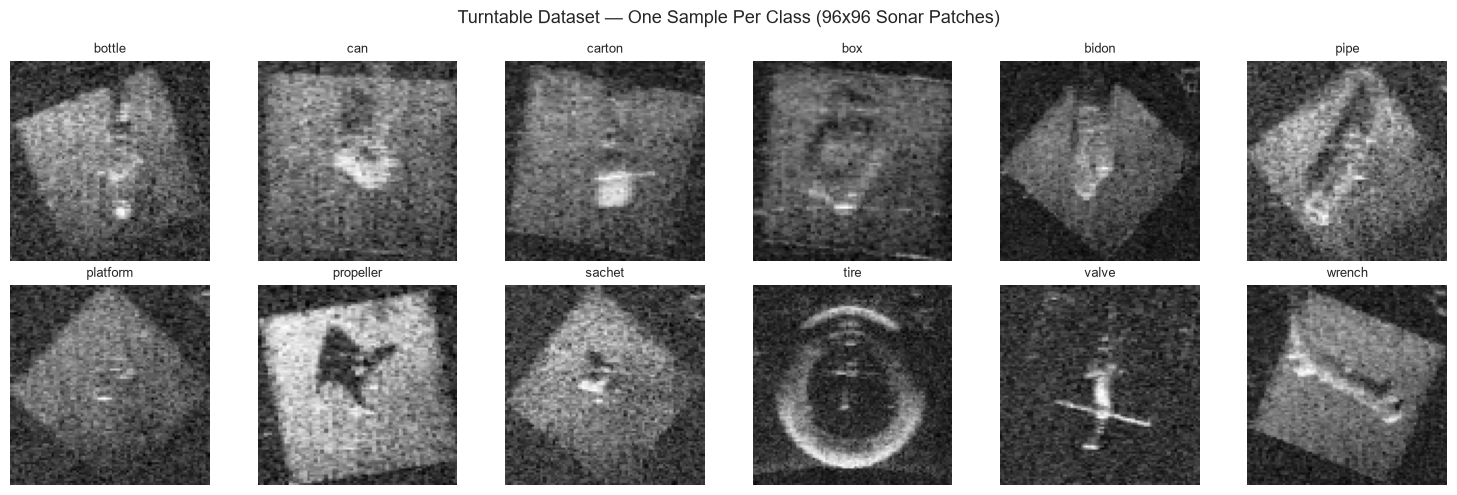

In [5]:
fig, axes = plt.subplots(2, 6, figsize=(15, 5))
fig.suptitle('Turntable Dataset — One Sample Per Class (96x96 Sonar Patches)', fontsize=13)

for idx, cls_name in enumerate(tt_classes):
    ax = axes[idx // 6, idx % 6]
    cls_mask = tt_y_train == idx
    sample = tt_x_train[cls_mask][0].squeeze()
    ax.imshow(sample, cmap='gray')
    ax.set_title(cls_name, fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.show()

## 3. Sample Images — Watertank Dataset
Patches extracted from full sonar scenes in a water tank. Includes a 'background' class.

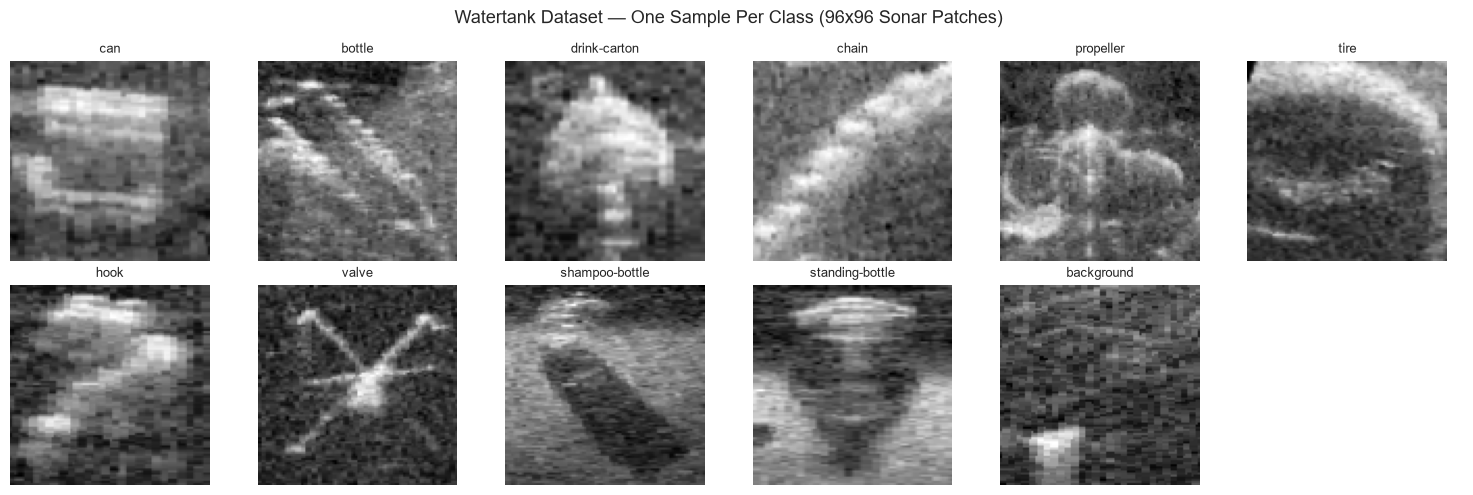

In [6]:
fig, axes = plt.subplots(2, 6, figsize=(15, 5))
fig.suptitle('Watertank Dataset — One Sample Per Class (96x96 Sonar Patches)', fontsize=13)

for idx, cls_name in enumerate(wt_classes):
    ax = axes[idx // 6, idx % 6]
    cls_mask = wt_y_train == idx
    sample = wt_x_train[cls_mask][0].squeeze()
    ax.imshow(sample, cmap='gray')
    ax.set_title(cls_name, fontsize=9)
    ax.axis('off')

# hide the last empty subplot (11 classes, 12 slots)
axes[1, 5].axis('off')
plt.tight_layout()
plt.show()

## 4. Sample Images — Quarry (Real-World, Unlabeled)
These patches come from an actual underwater quarry. No labels exist — used for domain shift analysis.

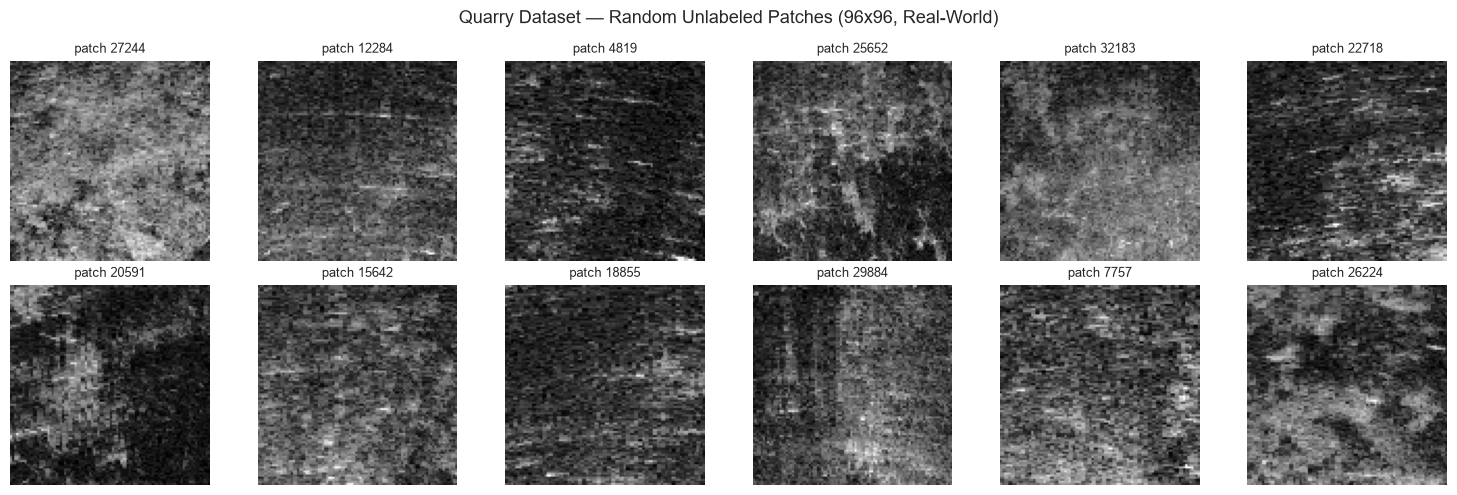

In [7]:
fig, axes = plt.subplots(2, 6, figsize=(15, 5))
fig.suptitle('Quarry Dataset — Random Unlabeled Patches (96x96, Real-World)', fontsize=13)

np.random.seed(42)
rand_idx = np.random.choice(len(qr_patches), 12, replace=False)
for i, idx in enumerate(rand_idx):
    ax = axes[i // 6, i % 6]
    ax.imshow(qr_patches[idx].squeeze(), cmap='gray')
    ax.set_title(f'patch {idx}', fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.show()

## 5. Full Sonar Scene Examples
Raw watertank and quarry images showing the characteristic fan-shaped sonar field of view.

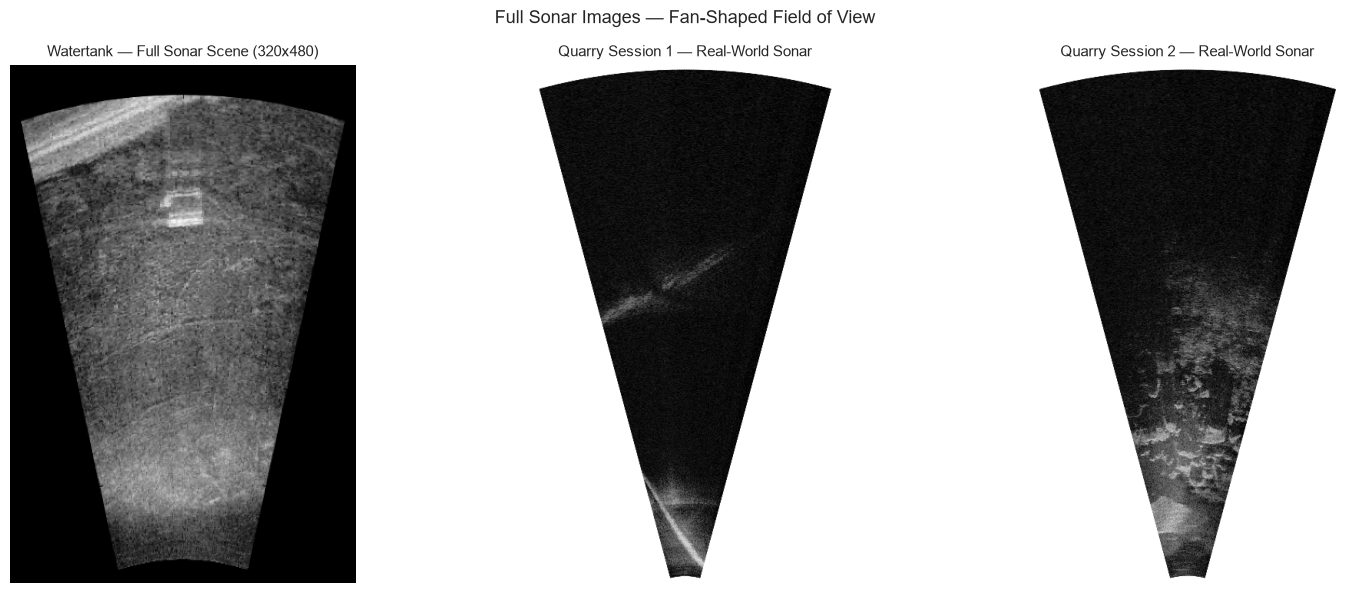

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

# Watertank full scene
wt_img_path = os.path.join(RAW_DATA, 'watertank-segmentation', 'Images', 'marine-debris-aris3k-0.png')
wt_img = cv2.imread(wt_img_path, cv2.IMREAD_GRAYSCALE)
axes[0].imshow(wt_img, cmap='gray')
axes[0].set_title('Watertank — Full Sonar Scene (320x480)', fontsize=11)
axes[0].axis('off')

# Quarry full scene (two different sessions)
qr_img1 = cv2.imread(os.path.join(RAW_DATA, 'quarry-fullsize', '2016-06-22_113541', '2016-06-22_113541-frame00000.png'), cv2.IMREAD_GRAYSCALE)
axes[1].imshow(qr_img1, cmap='gray')
axes[1].set_title('Quarry Session 1 — Real-World Sonar', fontsize=11)
axes[1].axis('off')

qr_img2 = cv2.imread(os.path.join(RAW_DATA, 'quarry-fullsize', '2016-06-22_143000', '2016-06-22_143000-frame00100.png'), cv2.IMREAD_GRAYSCALE)
axes[2].imshow(qr_img2, cmap='gray')
axes[2].set_title('Quarry Session 2 — Real-World Sonar', fontsize=11)
axes[2].axis('off')

plt.suptitle('Full Sonar Images — Fan-Shaped Field of View', fontsize=13)
plt.tight_layout()
plt.show()

## 6. Bounding Box Annotations — Watertank Detection
Showing XML bounding box annotations overlaid on watertank sonar images.

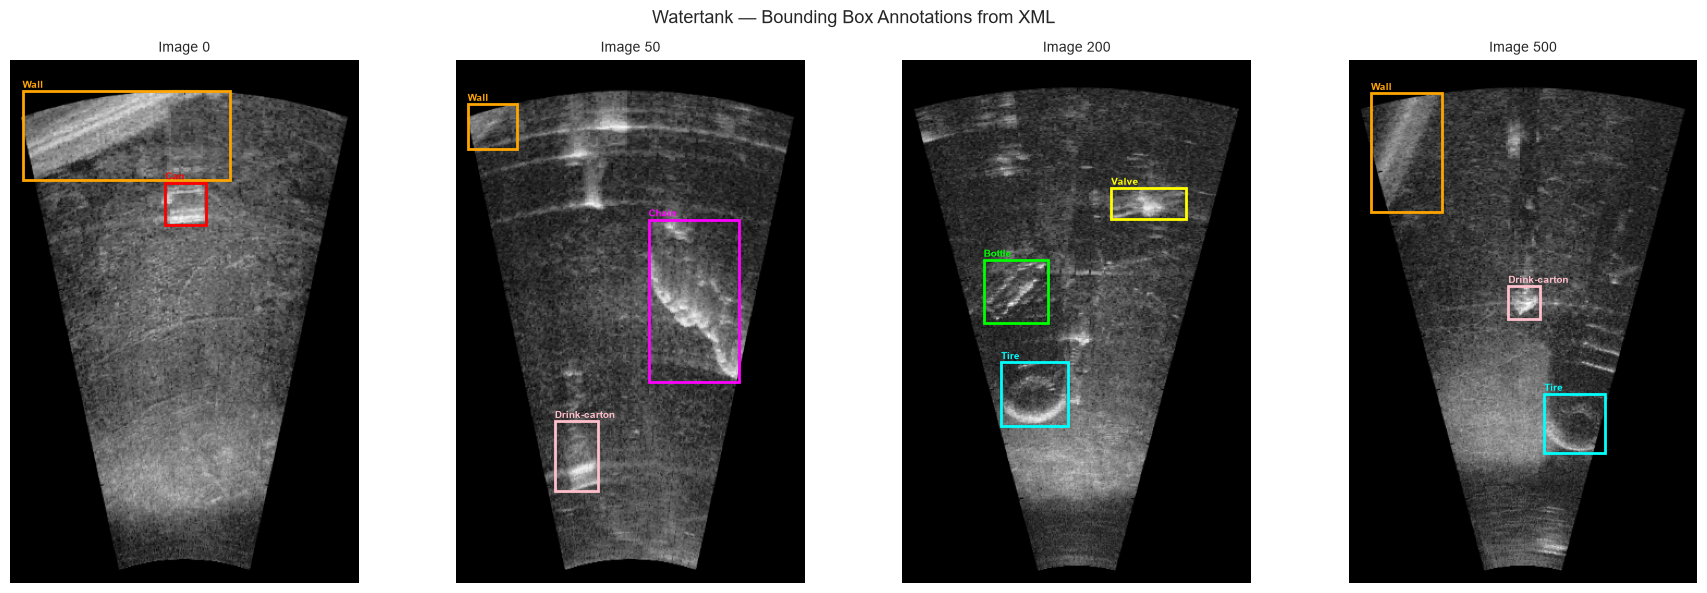

In [9]:
def parse_xml_annotation(xml_path):
    """Parse a watertank bounding box XML file."""
    tree = ET.parse(xml_path)
    root = tree.getroot()
    objects = []
    for obj in root.findall('object'):
        name = obj.find('name').text
        bbox = obj.find('bndbox')
        x = int(bbox.find('x').text)
        y = int(bbox.find('y').text)
        w = int(bbox.find('w').text)
        h = int(bbox.find('h').text)
        objects.append({'name': name, 'x': x, 'y': y, 'w': w, 'h': h})
    return objects

bbox_dir = os.path.join(RAW_DATA, 'watertank-segmentation', 'BoxAnnotations')
img_dir  = os.path.join(RAW_DATA, 'watertank-segmentation', 'Images')

sample_ids = [0, 50, 200, 500]
colors = {'Can': 'red', 'Bottle': 'lime', 'Tire': 'cyan', 'Valve': 'yellow',
          'Wall': 'orange', 'Chain': 'magenta', 'Hook': 'white',
          'Propeller': 'deepskyblue', 'Drink-carton': 'pink',
          'Shampoo-bottle': 'gold', 'Standing-bottle': 'violet'}

fig, axes = plt.subplots(1, 4, figsize=(18, 6))
for i, sid in enumerate(sample_ids):
    img_path = os.path.join(img_dir, f'marine-debris-aris3k-{sid}.png')
    xml_path = os.path.join(bbox_dir, f'marine-debris-aris3k-{sid}.xml')
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    objs = parse_xml_annotation(xml_path)

    axes[i].imshow(img, cmap='gray')
    for obj in objs:
        color = colors.get(obj['name'], 'red')
        rect = mpatches.Rectangle((obj['x'], obj['y']), obj['w'], obj['h'],
                                   linewidth=2, edgecolor=color, facecolor='none')
        axes[i].add_patch(rect)
        axes[i].text(obj['x'], obj['y'] - 3, obj['name'], fontsize=7,
                     color=color, fontweight='bold')
    axes[i].set_title(f'Image {sid}', fontsize=10)
    axes[i].axis('off')

plt.suptitle('Watertank — Bounding Box Annotations from XML', fontsize=13)
plt.tight_layout()
plt.show()

## 7. Class Distribution — Turntable (12 Classes)

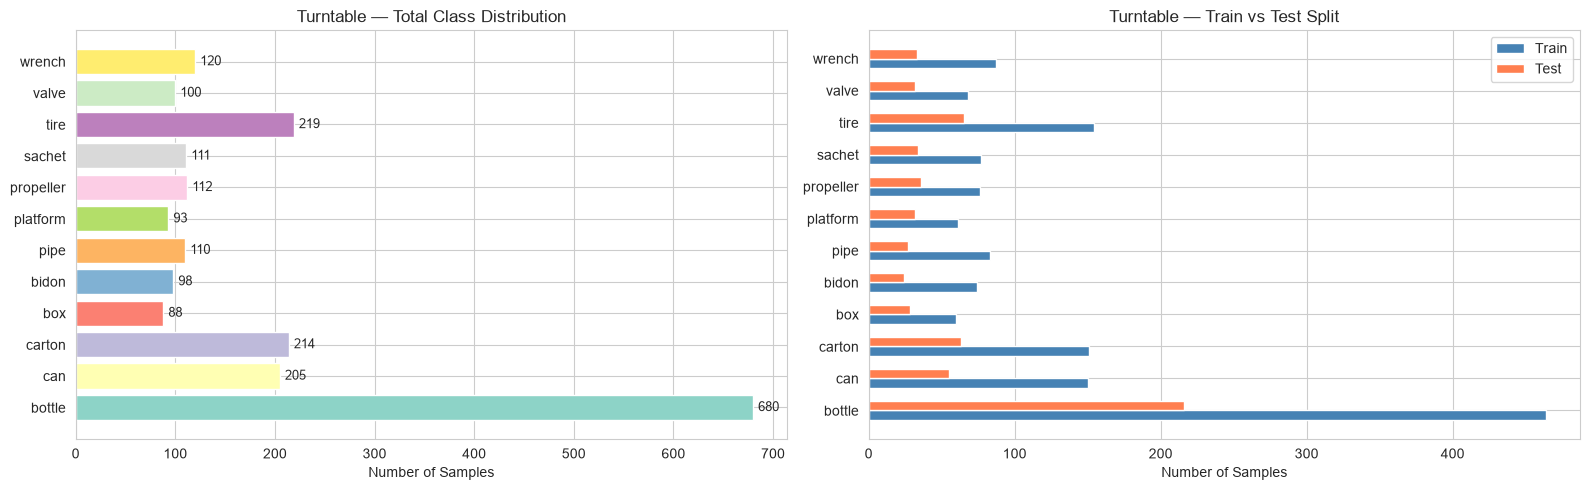

Imbalance ratio (max/min): 7.7x
Most samples: bottle (680)
Fewest samples: box (88)


In [10]:
tt_all_labels = np.concatenate([tt_y_train, tt_y_test])
tt_counts = Counter(tt_all_labels)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Total distribution
classes_sorted = sorted(tt_counts.keys())
counts = [tt_counts[c] for c in classes_sorted]
names = [tt_classes[c] for c in classes_sorted]
bar_colors = sns.color_palette('Set3', len(names))

axes[0].barh(names, counts, color=bar_colors)
axes[0].set_xlabel('Number of Samples')
axes[0].set_title('Turntable — Total Class Distribution')
for j, v in enumerate(counts):
    axes[0].text(v + 5, j, str(v), va='center', fontsize=9)

# Train vs Test split
train_counts = Counter(tt_y_train)
test_counts = Counter(tt_y_test)
x_pos = np.arange(len(names))
axes[1].barh(x_pos - 0.15, [train_counts[c] for c in classes_sorted], height=0.3, label='Train', color='steelblue')
axes[1].barh(x_pos + 0.15, [test_counts[c] for c in classes_sorted], height=0.3, label='Test', color='coral')
axes[1].set_yticks(x_pos)
axes[1].set_yticklabels(names)
axes[1].set_xlabel('Number of Samples')
axes[1].set_title('Turntable — Train vs Test Split')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'Imbalance ratio (max/min): {max(counts)/min(counts):.1f}x')
print(f'Most samples: {names[np.argmax(counts)]} ({max(counts)})')
print(f'Fewest samples: {names[np.argmin(counts)]} ({min(counts)})')

## 8. Class Distribution — Watertank (11 Classes)

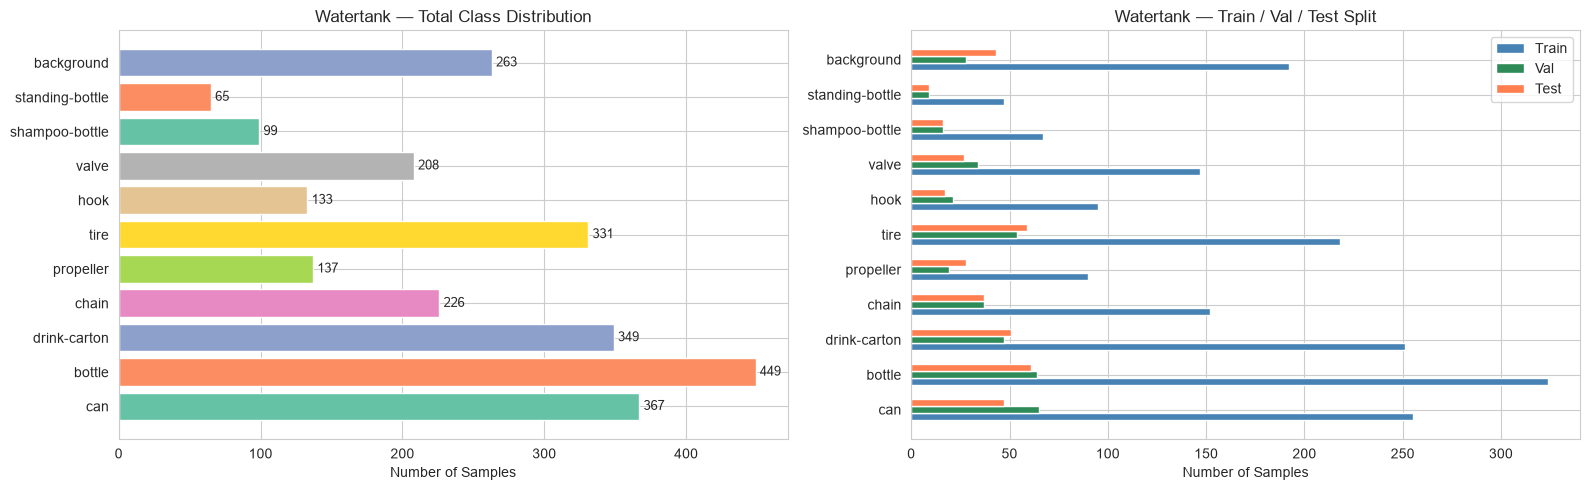

Imbalance ratio (max/min): 6.9x
Most samples: bottle (449)
Fewest samples: standing-bottle (65)


In [11]:
wt_all_labels = np.concatenate([wt_y_train, wt_y_val, wt_y_test])
wt_counts = Counter(wt_all_labels)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Total distribution
classes_sorted_wt = sorted(wt_counts.keys())
counts_wt = [wt_counts[c] for c in classes_sorted_wt]
names_wt = [wt_classes[c] for c in classes_sorted_wt]
bar_colors_wt = sns.color_palette('Set2', len(names_wt))

axes[0].barh(names_wt, counts_wt, color=bar_colors_wt)
axes[0].set_xlabel('Number of Samples')
axes[0].set_title('Watertank — Total Class Distribution')
for j, v in enumerate(counts_wt):
    axes[0].text(v + 3, j, str(v), va='center', fontsize=9)

# Train / Val / Test split
train_c = Counter(wt_y_train)
val_c   = Counter(wt_y_val)
test_c  = Counter(wt_y_test)
x_pos = np.arange(len(names_wt))
axes[1].barh(x_pos - 0.2, [train_c[c] for c in classes_sorted_wt], height=0.2, label='Train', color='steelblue')
axes[1].barh(x_pos,       [val_c[c] for c in classes_sorted_wt],   height=0.2, label='Val', color='seagreen')
axes[1].barh(x_pos + 0.2, [test_c[c] for c in classes_sorted_wt],  height=0.2, label='Test', color='coral')
axes[1].set_yticks(x_pos)
axes[1].set_yticklabels(names_wt)
axes[1].set_xlabel('Number of Samples')
axes[1].set_title('Watertank — Train / Val / Test Split')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'Imbalance ratio (max/min): {max(counts_wt)/min(counts_wt):.1f}x')
print(f'Most samples: {names_wt[np.argmax(counts_wt)]} ({max(counts_wt)})')
print(f'Fewest samples: {names_wt[np.argmin(counts_wt)]} ({min(counts_wt)})')

## 9. Detection Annotation Statistics
Analyzing the bounding box annotations from the watertank XML files.

Total annotation files: 1868


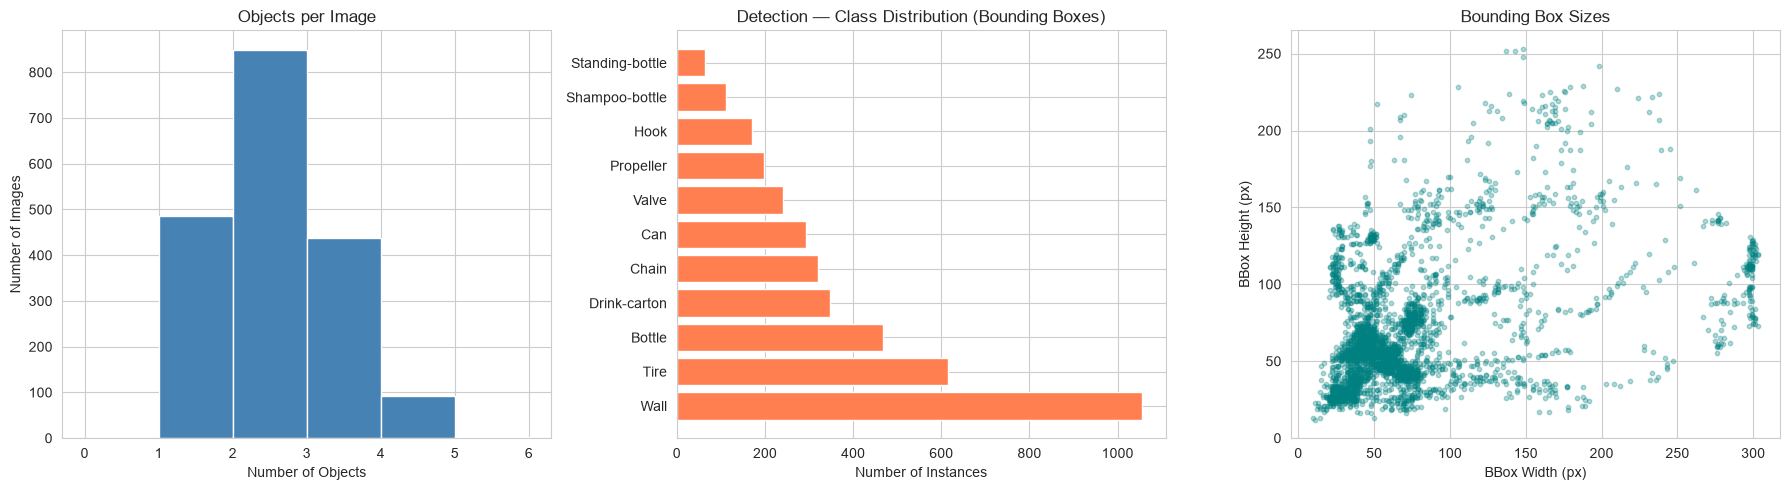

Avg objects per image: 2.1
Avg bbox size: 74 x 67 px
Total bounding boxes: 3882


In [12]:
xml_files = glob.glob(os.path.join(bbox_dir, '*.xml'))
print(f'Total annotation files: {len(xml_files)}')

all_objects = []
objects_per_image = []
bbox_widths = []
bbox_heights = []
class_counter = Counter()

for xf in xml_files:
    objs = parse_xml_annotation(xf)
    objects_per_image.append(len(objs))
    for obj in objs:
        class_counter[obj['name']] += 1
        bbox_widths.append(obj['w'])
        bbox_heights.append(obj['h'])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Objects per image
axes[0].hist(objects_per_image, bins=range(0, max(objects_per_image)+2), color='steelblue', edgecolor='white')
axes[0].set_xlabel('Number of Objects')
axes[0].set_ylabel('Number of Images')
axes[0].set_title('Objects per Image')

# Detection class distribution
det_names = list(class_counter.keys())
det_counts = list(class_counter.values())
sorted_idx = np.argsort(det_counts)[::-1]
axes[1].barh([det_names[i] for i in sorted_idx], [det_counts[i] for i in sorted_idx], color='coral')
axes[1].set_xlabel('Number of Instances')
axes[1].set_title('Detection — Class Distribution (Bounding Boxes)')

# Bounding box size distribution
axes[2].scatter(bbox_widths, bbox_heights, alpha=0.3, s=10, color='teal')
axes[2].set_xlabel('BBox Width (px)')
axes[2].set_ylabel('BBox Height (px)')
axes[2].set_title('Bounding Box Sizes')

plt.tight_layout()
plt.show()

print(f'Avg objects per image: {np.mean(objects_per_image):.1f}')
print(f'Avg bbox size: {np.mean(bbox_widths):.0f} x {np.mean(bbox_heights):.0f} px')
print(f'Total bounding boxes: {sum(det_counts)}')

## 10. Pixel Intensity Distributions
Comparing how pixel values are distributed across the three settings.

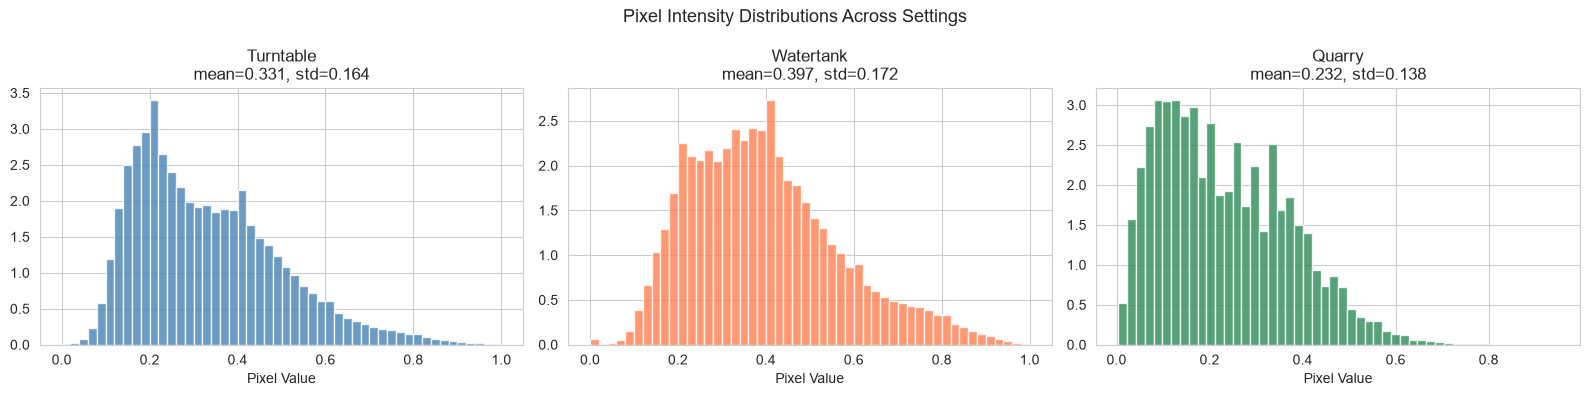

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Turntable
tt_flat = tt_x_train.flatten()
axes[0].hist(tt_flat, bins=50, color='steelblue', alpha=0.8, density=True)
axes[0].set_title(f'Turntable\nmean={tt_flat.mean():.3f}, std={tt_flat.std():.3f}')
axes[0].set_xlabel('Pixel Value')

# Watertank
wt_flat = wt_x_train.flatten()
axes[1].hist(wt_flat, bins=50, color='coral', alpha=0.8, density=True)
axes[1].set_title(f'Watertank\nmean={wt_flat.mean():.3f}, std={wt_flat.std():.3f}')
axes[1].set_xlabel('Pixel Value')

# Quarry
qr_flat = (qr_patches[:5000].astype(np.float32) / 255.0).flatten()
axes[2].hist(qr_flat, bins=50, color='seagreen', alpha=0.8, density=True)
axes[2].set_title(f'Quarry\nmean={qr_flat.mean():.3f}, std={qr_flat.std():.3f}')
axes[2].set_xlabel('Pixel Value')

plt.suptitle('Pixel Intensity Distributions Across Settings', fontsize=13)
plt.tight_layout()
plt.show()

## 11. Visual Comparison — Same Object Across Settings
Showing how the same type of debris looks different in turntable vs watertank vs quarry.

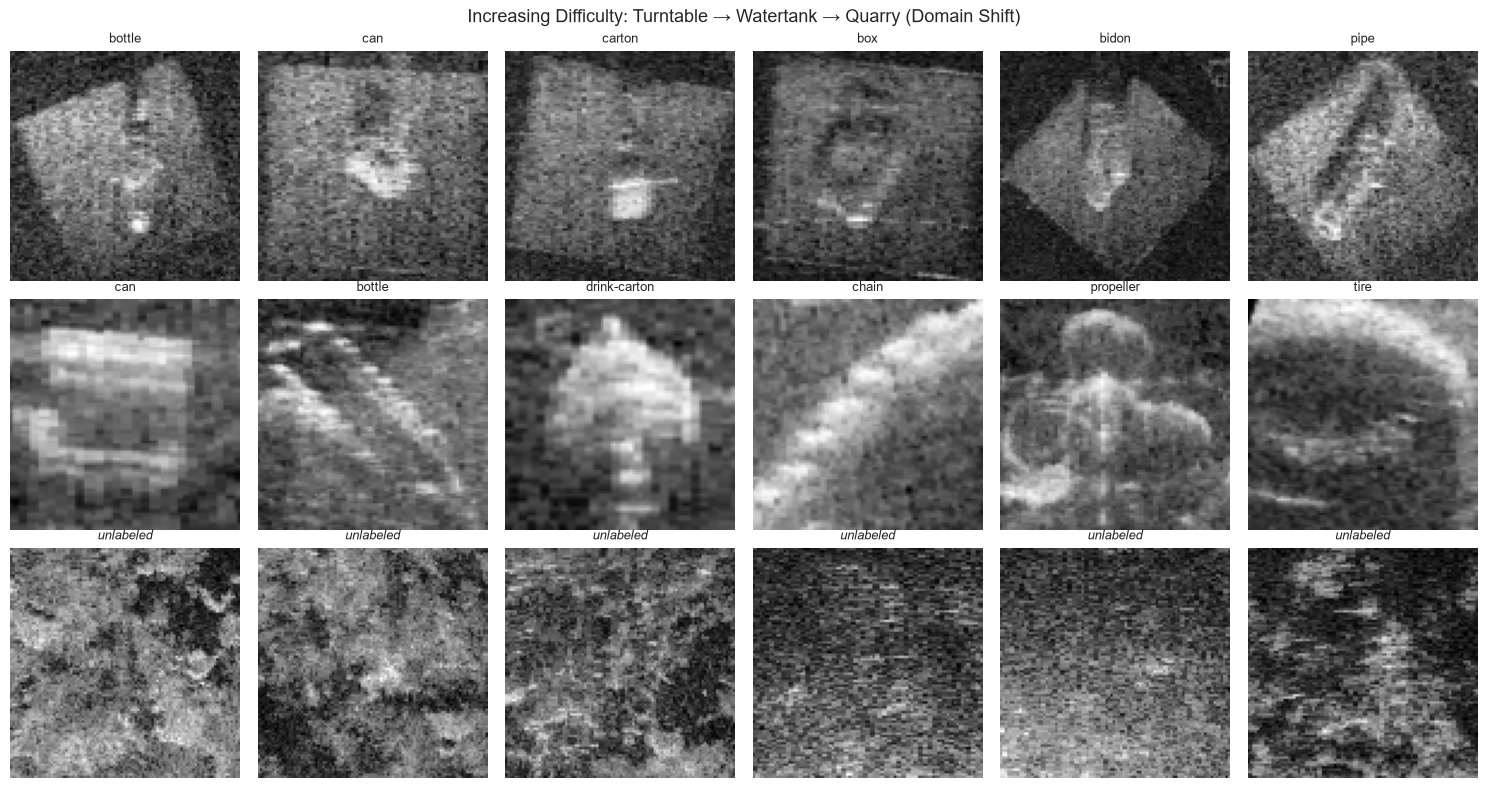

In [14]:
fig, axes = plt.subplots(3, 6, figsize=(15, 8))

# Row 1: Turntable samples (clean, controlled)
axes[0, 0].set_ylabel('Turntable\n(controlled)', fontsize=11, fontweight='bold')
for i in range(6):
    mask = tt_y_train == i
    axes[0, i].imshow(tt_x_train[mask][0].squeeze(), cmap='gray')
    axes[0, i].set_title(tt_classes[i], fontsize=9)
    axes[0, i].axis('off')

# Row 2: Watertank samples (in-water, noisier)
axes[1, 0].set_ylabel('Watertank\n(in water)', fontsize=11, fontweight='bold')
for i in range(6):
    mask = wt_y_train == i
    axes[1, i].imshow(wt_x_train[mask][0].squeeze(), cmap='gray')
    axes[1, i].set_title(wt_classes[i], fontsize=9)
    axes[1, i].axis('off')

# Row 3: Quarry random patches (real world, unknown)
axes[2, 0].set_ylabel('Quarry\n(real world)', fontsize=11, fontweight='bold')
np.random.seed(7)
for i in range(6):
    idx = np.random.randint(len(qr_patches))
    axes[2, i].imshow(qr_patches[idx].squeeze(), cmap='gray')
    axes[2, i].set_title('unlabeled', fontsize=9, fontstyle='italic')
    axes[2, i].axis('off')

plt.suptitle('Increasing Difficulty: Turntable → Watertank → Quarry (Domain Shift)', fontsize=13)
plt.tight_layout()
plt.show()

## 12. Dataset Summary Table

In [15]:
print('=' * 75)
print(f'{"Dataset":<15} {"Samples":<10} {"Classes":<10} {"Resolution":<12} {"Labels":<15} {"Setting"}')
print('=' * 75)
print(f'{"Turntable":<15} {tt_x_train.shape[0]+tt_x_test.shape[0]:<10} {len(tt_classes):<10} {"96x96":<12} {"Class":<15} {"Lab (dry)"}')
print(f'{"Watertank":<15} {wt_x_train.shape[0]+wt_x_val.shape[0]+wt_x_test.shape[0]:<10} {len(wt_classes):<10} {"96x96":<12} {"Class+BBox":<15} {"Lab (water)"}')
print(f'{"Quarry":<15} {qr_patches.shape[0]:<10} {"None":<10} {"96x96":<12} {"None":<15} {"Real world"}')
print('=' * 75)
print(f'\nKey observation: Data goes from controlled → noisy → real-world.')
print(f'This represents the DOMAIN SHIFT challenge in marine debris detection.')

Dataset         Samples    Classes    Resolution   Labels          Setting
Turntable       2150       12         96x96        Class           Lab (dry)
Watertank       2627       11         96x96        Class+BBox      Lab (water)
Quarry          32184      None       96x96        None            Real world

Key observation: Data goes from controlled → noisy → real-world.
This represents the DOMAIN SHIFT challenge in marine debris detection.
